Introduction

Artificial Intelligence (AI) is becoming a major new source of electricity demand as data centres scale to support large language models, high-performance computing, and real-time inference. Global forecasts show AI-related electricity use growing rapidly over the next decade, with implications for energy planning, infrastructure investment, and grid stability.

For South Africa, the challenge is not the size of demand relative to global consumption, but the speed and distribution of adoption across industries. AI uptake follows S-curve diffusion patterns rather than linear growth, meaning electricity demand can escalate quickly once the technology becomes economically attractive. This makes it important to understand which sectors will adopt AI first, how fast adoption may occur, and where demand will concentrate geographically.

This analysis uses scenario-based S-curve models to project AI workload growth across key South African industries under Low, Base, and High adoption pathways. By comparing these results to global AI electricity trends, the model highlights the potential impact on local grids, identifies risks of regional bottlenecks, and shows why private renewable generation and data-centre-led infrastructure will be central to supporting South Africa’s AI ecosystem.

### Preview of Data ###


,Year,Base_TWh,LiftOff_TWh,HighEfficiency_TWh,Headwinds_TWh
0,2024,415.000000,539.500000,332.000000,373.500000
1,2025,476.005585,618.807261,380.804468,428.405027
2,2026,545.979078,709.772801,436.783262,491.381170
3,2027,626.238772,814.110404,500.991018,563.614895
4,2028,718.296755,933.785782,574.637404,646.467080



### Summary Statistics ###


,Year,Base_TWh,LiftOff_TWh,HighEfficiency_TWh,Headwinds_TWh
count,12.000000,12.000000,12.000000,12.000000,12.000000
mean,2029.500000,984.609300,1279.992089,787.687440,886.148370
std,3.605551,476.009912,618.812886,380.807930,428.408921
min,2024.000000,415.000000,539.500000,332.000000,373.500000
25%,2026.750000,606.173849,788.026003,484.939079,545.556464
50%,2029.500000,884.443696,1149.776804,707.554957,795.999326
75%,2032.250000,1288.943570,1675.626640,1031.154856,1160.049213
max,2035.000000,1876.080927,2438.905206,1500.864742,1688.472835



### Year-over-Year Growth Rates ###


...


### Scenario CAGRs (2024 → 2035) ###


'Base_TWh: 14.70%'

'LiftOff_TWh: 14.70%'

'HighEfficiency_TWh: 14.70%'

'Headwinds_TWh: 14.70%'

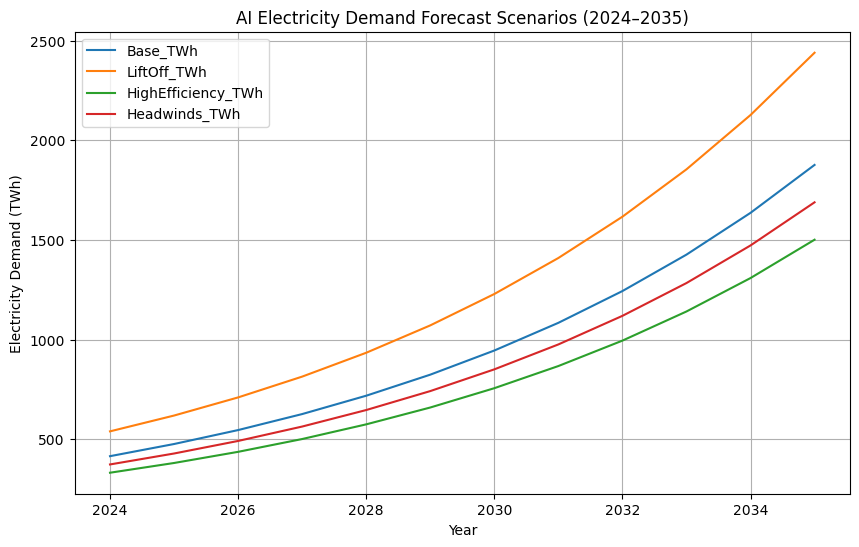

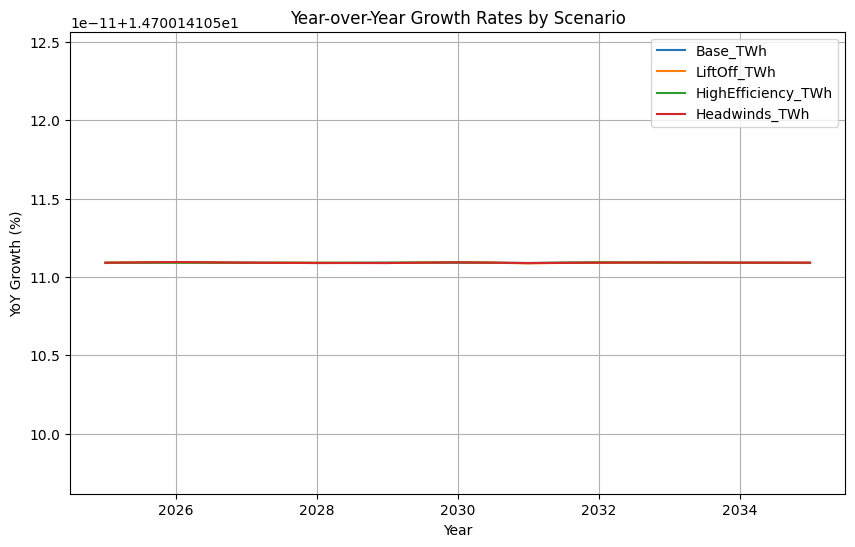

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load the CSV
# -----------------------------
url = "ai_energy_forecast_scenarios.csv"  # If hosted locally or in same directory
df = pd.read_csv(url)

print("### Preview of Data ###")
display(df.head())

# -----------------------------
# 2. Summary Statistics
# -----------------------------
print("\n### Summary Statistics ###")
display(df.describe())

# -----------------------------
# 3. Compute Annual Growth Rates for Each Scenario
# -----------------------------
scenario_cols = ["Base_TWh", "LiftOff_TWh", "HighEfficiency_TWh", "Headwinds_TWh"]

for col in scenario_cols:
    df[col + "_YoY_Growth"] = df[col].pct_change() * 100  # as %
    
print("\n### Year-over-Year Growth Rates ###")
display(df[["Year"] + [c+"_YoY_Growth" for c in scenario_cols]].tail())

# -----------------------------
# 4. CAGR Calculation Helper
# -----------------------------
def cagr(start, end, years):
    return (end / start)**(1/years) - 1

print("\n### Scenario CAGRs (2024 → 2035) ###")
for col in scenario_cols:
    start = df[col].iloc[0]
    end = df[col].iloc[-1]
    years = df["Year"].iloc[-1] - df["Year"].iloc[0]
    display(f"{col}: {cagr(start, end, years)*100:.2f}%")

# -----------------------------
# 5. Plotting the Scenarios
# -----------------------------
plt.figure(figsize=(10,6))
for col in scenario_cols:
    plt.plot(df["Year"], df[col], label=col)

plt.xlabel("Year")
plt.ylabel("Electricity Demand (TWh)")
plt.title("AI Electricity Demand Forecast Scenarios (2024–2035)")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 6. Plot YoY Growth Rates
# -----------------------------
plt.figure(figsize=(10,6))
for col in scenario_cols:
    growth_col = col + "_YoY_Growth"
    plt.plot(df["Year"], df[growth_col], label=col)

plt.xlabel("Year")
plt.ylabel("YoY Growth (%)")
plt.title("Year-over-Year Growth Rates by Scenario")
plt.legend()
plt.grid(True)
plt.show()


### South Africa Scenario Table (first rows) ###


,Year,Financial_Services_Adoption_Low,Financial_Services_Demand_TWh_Low,Retail_ECommerce_Adoption_Low,Retail_ECommerce_Demand_TWh_Low,Manufacturing_Mining_Adoption_Low,Manufacturing_Mining_Demand_TWh_Low,PublicSector_Education_Adoption_Low,PublicSector_Education_Demand_TWh_Low,Agriculture_Adoption_Low,...,Retail_ECommerce_Demand_TWh_High,Manufacturing_Mining_Adoption_High,Manufacturing_Mining_Demand_TWh_High,PublicSector_Education_Adoption_High,PublicSector_Education_Demand_TWh_High,Agriculture_Adoption_High,Agriculture_Demand_TWh_High,ICT_DataCentres_Adoption_High,ICT_DataCentres_Demand_TWh_High,Total_SA_AI_Demand_TWh_High
0,2025,0.053527,0.142383,0.051635,0.075904,0.052442,0.165193,0.047681,0.040052,0.042462,...,0.459995,0.122485,0.716538,0.092590,0.144441,0.077341,0.060326,0.329278,2.653980,5.249003
1,2026,0.081047,0.215585,0.070913,0.104242,0.065562,0.206519,0.056740,0.047662,0.049648,...,0.588801,0.147918,0.865319,0.107577,0.167819,0.088727,0.069207,0.450000,3.627000,6.953072
2,2027,0.120573,0.320725,0.096231,0.141459,0.081426,0.256492,0.067193,0.056442,0.057822,...,0.733547,0.176452,1.032243,0.124010,0.193456,0.101168,0.078911,0.570722,4.600020,8.737676
3,2028,0.174990,0.465473,0.128580,0.189013,0.100334,0.316052,0.079126,0.066466,0.067041,...,0.887250,0.207647,1.214737,0.141737,0.221110,0.114588,0.089378,0.675234,5.442387,10.418937
4,2029,0.245693,0.653543,0.168496,0.247690,0.122485,0.385828,0.092590,0.077776,0.077341,...,1.040953,0.240803,1.408697,0.160525,0.250419,0.128866,0.100515,0.755002,6.085316,11.871177
5,2030,0.330957,0.880345,0.215678,0.317047,0.147918,0.465941,0.107577,0.090364,0.088727,...,1.185699,0.275000,1.608750,0.180066,0.280904,0.143836,0.112192,0.810225,6.530410,13.052505
6,2031,0.425000,1.130500,0.268699,0.394987,0.176452,0.555823,0.124010,0.104169,0.101168,...,1.314505,0.309197,1.808803,0.200000,0.312000,0.159292,0.124248,0.845922,6.818131,13.981055
7,2032,0.519043,1.380655,0.325000,0.477750,0.207647,0.654089,0.141737,0.119059,0.114588,...,1.423475,0.342353,2.002763,0.219934,0.343096,0.175000,0.136500,0.867986,6.995967,14.700429
8,2033,0.604307,1.607457,0.381301,0.560513,0.240803,0.758529,0.160525,0.134841,0.128866,...,1.511790,0.373548,2.185257,0.239475,0.373581,0.190708,0.148752,0.881247,7.102853,15.256809
9,2034,0.675010,1.795527,0.434322,0.638453,0.275000,0.866250,0.180066,0.151256,0.143836,...,1.580908,0.402082,2.352181,0.258263,0.402890,0.206164,0.160808,0.889084,7.166020,15.689264



### SA + Global Data Comparison (first rows) ###


,Year,Total_SA_AI_Demand_TWh_Low,Total_SA_AI_Demand_TWh_Base,Total_SA_AI_Demand_TWh_High,Base_TWh
0,2025,0.676064,2.040992,5.249003,476.005585
1,2026,0.984486,2.915208,6.953072,545.979078
2,2027,1.428695,4.037694,8.737676,626.238772
3,2028,2.040646,5.348517,10.418937,718.296755
4,2029,2.826386,6.721289,11.871177,823.887391
5,2030,3.743962,8.014567,13.052505,945.000000
6,2031,4.704902,9.131674,13.981055,1083.916333
7,2032,5.610197,10.040388,14.700429,1243.253563
8,2033,6.392172,10.754658,15.256809,1426.013590
9,2034,7.028272,11.308022,15.689264,1635.639599


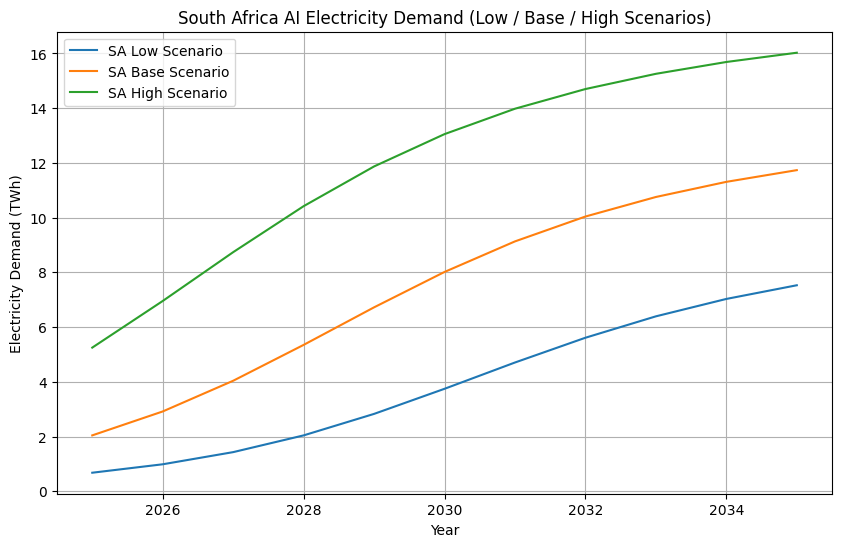

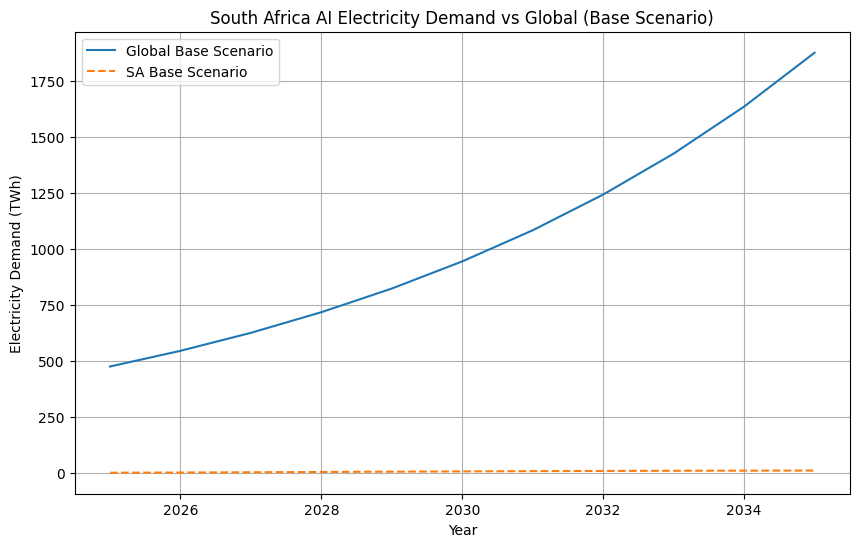

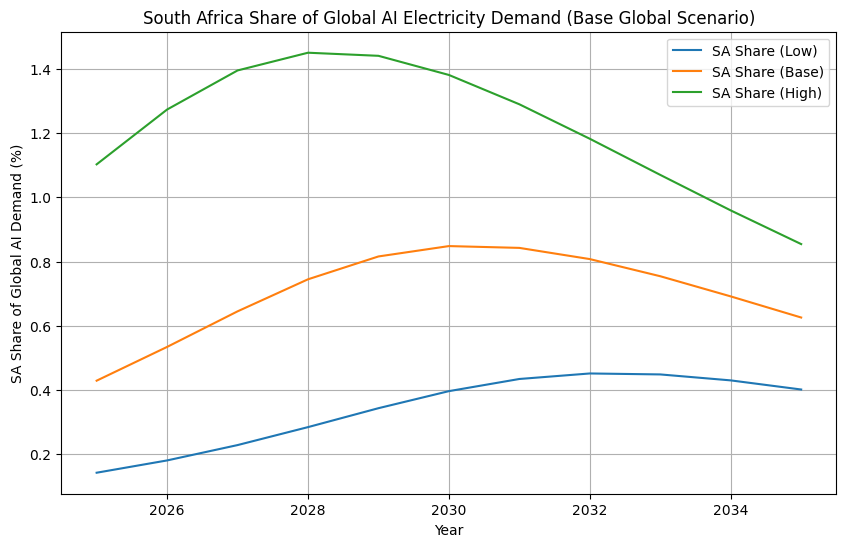

In [2]:
# TAKING A LOOK AT THE SOUTH AFRICAN CONTEXT
# ==========================================================
# 1. MODEL SETTINGS
# ==========================================================

start_year = 2025
end_year = 2035
years = np.arange(start_year, end_year + 1)

# Logistic adoption function
def logistic(t, K, r, t0):
    return K / (1.0 + np.exp(-r * (t - t0)))

# Base sector parameters
SECTORS_BASE = {
    "Financial_Services":      {"K": 0.85, "r": 0.45, "t0": 2029, "E": 3.8},
    "Retail_ECommerce":        {"K": 0.65, "r": 0.35, "t0": 2030, "E": 2.1},
    "Manufacturing_Mining":    {"K": 0.55, "r": 0.25, "t0": 2032, "E": 4.5},
    "PublicSector_Education":  {"K": 0.40, "r": 0.20, "t0": 2033, "E": 1.2},
    "Agriculture":             {"K": 0.35, "r": 0.18, "t0": 2034, "E": 0.6},
    "ICT_DataCentres":         {"K": 0.90, "r": 0.55, "t0": 2028, "E": 6.2},
}

# Scenario scaling settings
SCENARIOS = {
    "Low": {
        "E_scale": 0.7,          # lower energy demand
        "t0_shift": 2,           # adoption begins later
    },
    "Base": {
        "E_scale": 1.0,
        "t0_shift": 0,
    },
    "High": {
        "E_scale": 1.3,          # higher energy demand
        "t0_shift": -2,          # adoption begins earlier
    },
}

# ==========================================================
# 2. BUILD SA SCENARIOS
# ==========================================================

def build_sa_scenario(name, sector_params, years):
    """Return DataFrame of adoption and demand for one scenario."""
    s = SCENARIOS[name]
    df = pd.DataFrame({"Year": years})

    for sector, params in sector_params.items():
        K = params["K"]
        r = params["r"]
        t0 = params["t0"] + s["t0_shift"]
        E = params["E"] * s["E_scale"]

        adoption_col = f"{sector}_Adoption_{name}"
        demand_col = f"{sector}_Demand_TWh_{name}"

        df[adoption_col] = logistic(df["Year"], K, r, t0)
        df[demand_col] = df[adoption_col] * E

    # Sum of sector demand
    demand_cols = [c for c in df.columns if c.endswith(f"Demand_TWh_{name}")]
    df[f"Total_SA_AI_Demand_TWh_{name}"] = df[demand_cols].sum(axis=1)

    return df


# Construct all scenarios
df_low = build_sa_scenario("Low",  SECTORS_BASE, years)
df_base = build_sa_scenario("Base", SECTORS_BASE, years)
df_high = build_sa_scenario("High", SECTORS_BASE, years)

# Merge into full table
df_sa_all = df_low.merge(df_base, on="Year").merge(df_high, on="Year")

print("### South Africa Scenario Table (first rows) ###")
display(df_sa_all.head(11))

# ==========================================================
# 3. LOAD GLOBAL SCENARIO CSV & MERGE
# ==========================================================
global_csv = "ai_energy_forecast_scenarios.csv"
df_global = pd.read_csv(global_csv)

df_merged = pd.merge(df_sa_all, df_global, on="Year", how="inner")

# Compute SA share of global Base scenario
df_merged["SA_Share_of_Global_Base_Low_%"] = (
    df_merged["Total_SA_AI_Demand_TWh_Low"]  / df_merged["Base_TWh"] * 100
)
df_merged["SA_Share_of_Global_Base_Base_%"] = (
    df_merged["Total_SA_AI_Demand_TWh_Base"] / df_merged["Base_TWh"] * 100
)
df_merged["SA_Share_of_Global_Base_High_%"] = (
    df_merged["Total_SA_AI_Demand_TWh_High"] / df_merged["Base_TWh"] * 100
)

print("\n### SA + Global Data Comparison (first rows) ###")
display(df_merged[[
    "Year",
    "Total_SA_AI_Demand_TWh_Low",
    "Total_SA_AI_Demand_TWh_Base",
    "Total_SA_AI_Demand_TWh_High",
    "Base_TWh"
]].head(11))

# ==========================================================
# 4. PLOTTING
# ==========================================================

# -- Plot 1: Total SA Demand (Low / Base / High) --
plt.figure(figsize=(10,6))
plt.plot(df_sa_all["Year"], df_sa_all["Total_SA_AI_Demand_TWh_Low"],  label="SA Low Scenario")
plt.plot(df_sa_all["Year"], df_sa_all["Total_SA_AI_Demand_TWh_Base"], label="SA Base Scenario")
plt.plot(df_sa_all["Year"], df_sa_all["Total_SA_AI_Demand_TWh_High"], label="SA High Scenario")

plt.xlabel("Year")
plt.ylabel("Electricity Demand (TWh)")
plt.title("South Africa AI Electricity Demand (Low / Base / High Scenarios)")
plt.grid(True)
plt.legend()
plt.show()

# -- Plot 2: SA vs Global Base Scenario --
plt.figure(figsize=(10,6))
plt.plot(df_merged["Year"], df_merged["Base_TWh"], label="Global Base Scenario")
plt.plot(df_merged["Year"], df_merged["Total_SA_AI_Demand_TWh_Base"], label="SA Base Scenario", linestyle="--")

plt.xlabel("Year")
plt.ylabel("Electricity Demand (TWh)")
plt.title("South Africa AI Electricity Demand vs Global (Base Scenario)")
plt.grid(True)
plt.legend()
plt.show()

# -- Plot 3: SA Share of Global Base --
plt.figure(figsize=(10,6))
plt.plot(df_merged["Year"], df_merged["SA_Share_of_Global_Base_Low_%"],  label="SA Share (Low)")
plt.plot(df_merged["Year"], df_merged["SA_Share_of_Global_Base_Base_%"], label="SA Share (Base)")
plt.plot(df_merged["Year"], df_merged["SA_Share_of_Global_Base_High_%"], label="SA Share (High)")

plt.xlabel("Year")
plt.ylabel("SA Share of Global AI Demand (%)")
plt.title("South Africa Share of Global AI Electricity Demand (Base Global Scenario)")
plt.grid(True)
plt.legend()
plt.show()

# ==========================================================
# Optional: Save Combined SA Scenarios to CSV
# ==========================================================
# df_sa_all.to_csv("south_africa_ai_scenarios.csv", index=False)


Conclusion

South Africa’s AI-driven electricity demand will grow quickly but unevenly, driven by timing of adoption rather than magnitude. The impact will be concentrated in specific industries and regions, stressing local infrastructure rather than national supply. Renewable private generation—not Eskom—is the most realistic way to support this growth.